# Calculo y Visualizacion de Normales en Superficies 3D

Este notebook cubre:
- Normales de **caras** (producto cruz + normalizacion).
- Normales de **vertices** (promedio de caras adyacentes).
- Comparacion **flat shading** vs **smooth shading**.
- Visualizacion de normales para debugging.
- Validacion de magnitud, orientacion e inversion de normales.

## 1) Instalacion de dependencias
Si ya las tienes instaladas, puedes omitir esta celda.

In [1]:
%%capture
%pip install -q trimesh numpy matplotlib scipy

## 2) Imports y funciones minimas

In [2]:
from pathlib import Path

import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

MEDIA_DIR = (Path("../media")).resolve()
MEDIA_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename):
    out = MEDIA_DIR / f"python_{filename}.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Figura guardada en: ../media/{out.name}")

def normalize_rows(v):
    n = np.linalg.norm(v, axis=1, keepdims=True)
    n[n == 0] = 1
    return v / n

def face_normals_manual(vertices, faces):
    tri = vertices[faces]
    v1 = tri[:, 1] - tri[:, 0]
    v2 = tri[:, 2] - tri[:, 0]
    normals = np.cross(v1, v2)
    return normalize_rows(normals)

def vertex_normals_from_faces(vertices, faces, face_normals):
    v_normals = np.zeros_like(vertices, dtype=float)
    for i, face in enumerate(faces):
        v_normals[face] += face_normals[i]
    return normalize_rows(v_normals)

## 3) Cargar modelo 3D (.obj, .stl, .gltf)

In [3]:
MODEL_PATH = "../media/low_poly_geometric_songbird_parus_major/scene.gltf"
## Si quieres probar otro modelo: MODEL_PATH = "./mi_modelo.obj"

path = Path(MODEL_PATH)
if path.exists():
    loaded = trimesh.load(path, force="mesh")
    mesh = loaded if isinstance(loaded, trimesh.Trimesh) else loaded.dump(concatenate=True)
    source_name = path.name
else:
    mesh = trimesh.creation.icosphere(subdivisions=3, radius=1.0)
    source_name = "icosphere_ejemplo"

if mesh.faces.shape[1] != 3:
    mesh = mesh.triangulate()

vertices = np.asarray(mesh.vertices)
faces = np.asarray(mesh.faces)

print(f"Modelo: {source_name}")
print(f"Vertices: {len(vertices)} | Caras: {len(faces)}")

Modelo: scene.gltf
Vertices: 109950 | Caras: 180740


## 4) Calculo de normales de caras

In [4]:
# normal = normalize(cross(B-A, C-A))
f_normals_manual = face_normals_manual(vertices, faces)

# Comparacion con trimesh
f_normals_tm = mesh.face_normals
cos_faces = np.sum(f_normals_manual * f_normals_tm, axis=1)
face_alignment = np.mean(cos_faces > 0.99)
print(f"Alineacion con trimesh.face_normals (>0.99): {face_alignment*100:.2f}%")

Alineacion con trimesh.face_normals (>0.99): 100.00%


## 5) Verificar orientacion de normales de caras (hacia afuera)

In [5]:
triangles = vertices[faces]
face_centers = triangles.mean(axis=1)
center = vertices.mean(axis=0)
radial = normalize_rows(face_centers - center)

dots = np.sum(f_normals_manual * radial, axis=1)
inverted_mask = dots < 0
outward_ratio = np.mean(dots > 0)

print(f"Consistencia hacia afuera: {outward_ratio*100:.2f}%")
print(f"Caras invertidas detectadas: {inverted_mask.sum()}")

Consistencia hacia afuera: 91.64%
Caras invertidas detectadas: 15114


## 6) Visualizar normales de caras como flechas

Figura guardada en: ../media/python_normales_caras_modelo.png


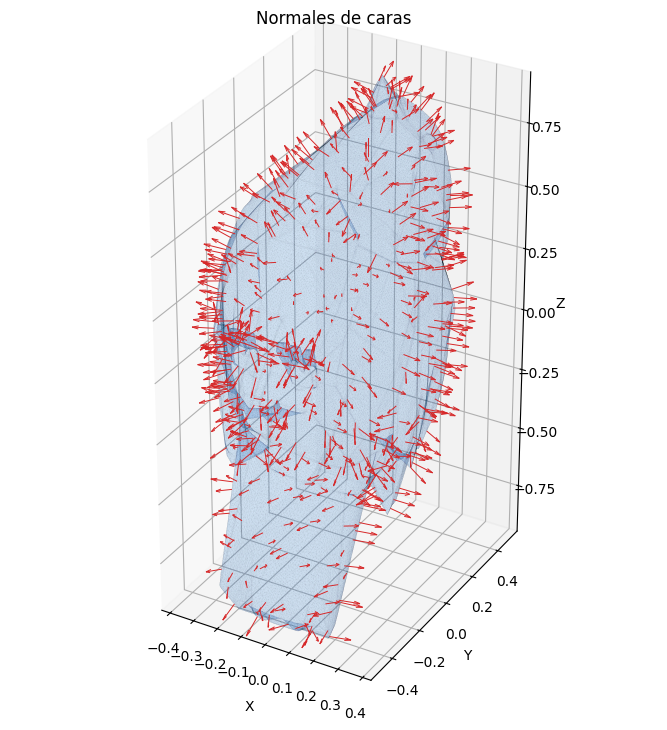

In [6]:
sample = min(600, len(faces))
idx = np.linspace(0, len(faces) - 1, sample, dtype=int)

fc = face_centers[idx]
fn = f_normals_manual[idx]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

mesh_overlay = Poly3DCollection(
    triangles,
    facecolors=(0.3, 0.6, 0.9, 0.12),
    edgecolors=(0.1, 0.1, 0.1, 0.08),
    linewidths=0.05,
    zsort="average",
)
ax.add_collection3d(mesh_overlay)

ax.quiver(
    fc[:, 0], fc[:, 1], fc[:, 2],
    fn[:, 0], fn[:, 1], fn[:, 2],
    length=0.08, normalize=True, color="tab:red", linewidth=0.7,
 )

mins = vertices.min(axis=0)
maxs = vertices.max(axis=0)
ax.set_xlim(mins[0], maxs[0])
ax.set_ylim(mins[1], maxs[1])
ax.set_zlim(mins[2], maxs[2])
ax.set_box_aspect((maxs - mins) + 1e-9)
ax.set_title("Normales de caras")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
save_fig(fig, "normales_caras_modelo")
plt.show()

## 7) Calculo de normales de vertices

In [7]:
v_normals_manual = vertex_normals_from_faces(vertices, faces, f_normals_manual)
v_normals_tm = mesh.vertex_normals

cos_v = np.sum(v_normals_manual * v_normals_tm, axis=1)
vertex_alignment = np.mean(cos_v > 0.99)
print(f"Alineacion con trimesh.vertex_normals (>0.99): {vertex_alignment*100:.2f}%")

Alineacion con trimesh.vertex_normals (>0.99): 97.01%


## 8) Visualizar normales de vertices

Figura guardada en: ../media/python_normales_vertices_modelo.png


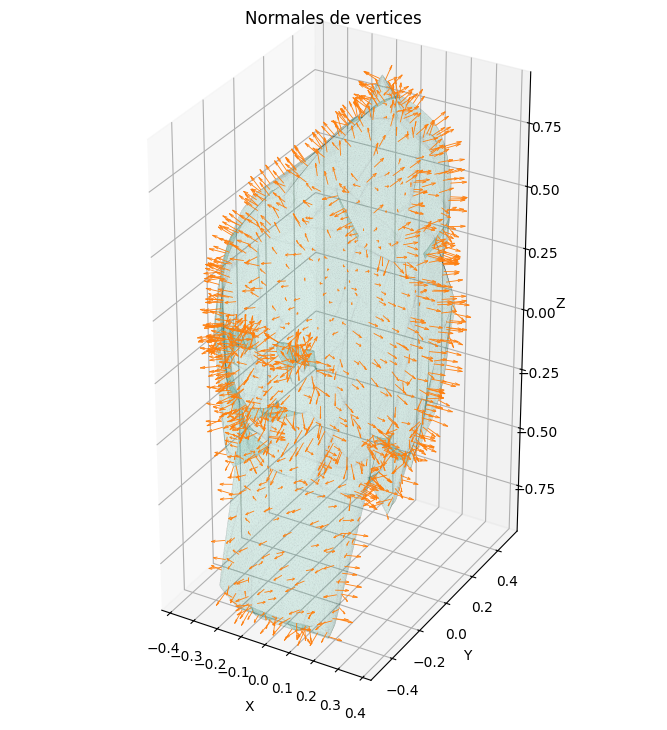

In [8]:
sample_v = min(1200, len(vertices))
idx_v = np.linspace(0, len(vertices) - 1, sample_v, dtype=int)

vv = vertices[idx_v]
vn = v_normals_manual[idx_v]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

mesh_overlay = Poly3DCollection(
    triangles,
    facecolors=(0.4, 0.8, 0.7, 0.10),
    edgecolors=(0.1, 0.1, 0.1, 0.06),
    linewidths=0.05,
    zsort="average",
)
ax.add_collection3d(mesh_overlay)

ax.quiver(
    vv[:, 0], vv[:, 1], vv[:, 2],
    vn[:, 0], vn[:, 1], vn[:, 2],
    length=0.06, normalize=True, color="tab:orange", linewidth=0.6,
 )

mins = vertices.min(axis=0)
maxs = vertices.max(axis=0)
ax.set_xlim(mins[0], maxs[0])
ax.set_ylim(mins[1], maxs[1])
ax.set_zlim(mins[2], maxs[2])
ax.set_box_aspect((maxs - mins) + 1e-9)
ax.set_title("Normales de vertices")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
save_fig(fig, "normales_vertices_modelo")
plt.show()

## 9) Comparacion Flat vs Smooth (lado a lado)
- Flat: iluminacion por normal de cara.
- Smooth: iluminacion por normales de vertices (promediadas por cara).

Figura guardada en: ../media/python_comparacion_flat_vs_smooth.png


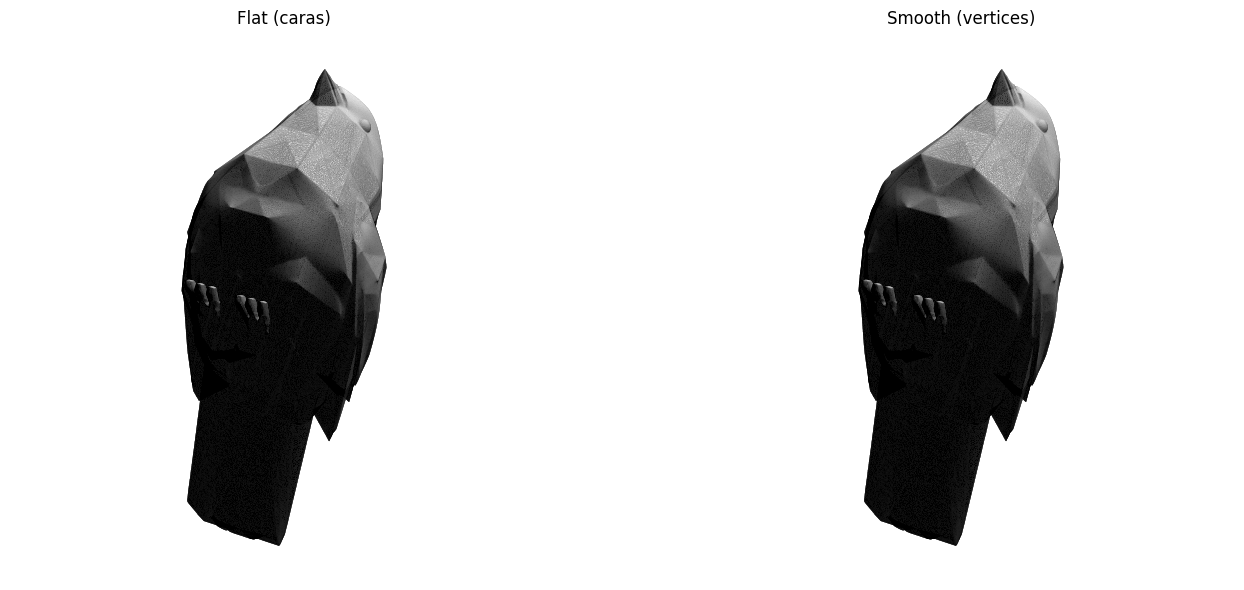

Analisis: Flat muestra facetas marcadas; Smooth genera transiciones mas suaves.


In [9]:
light_dir = np.array([0.3, 0.5, 1.0], dtype=float)
light_dir = light_dir / np.linalg.norm(light_dir)

flat_i = np.clip(f_normals_manual @ light_dir, 0, 1)
vert_i = np.clip(v_normals_manual @ light_dir, 0, 1)
smooth_i_face = vert_i[faces].mean(axis=1)

flat_colors = plt.cm.gray(flat_i)
smooth_colors = plt.cm.gray(smooth_i_face)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

pc1 = Poly3DCollection(triangles, facecolors=flat_colors, linewidths=0.05, edgecolors=(0, 0, 0, 0.1))
pc2 = Poly3DCollection(triangles, facecolors=smooth_colors, linewidths=0.05, edgecolors=(0, 0, 0, 0.1))
ax1.add_collection3d(pc1)
ax2.add_collection3d(pc2)

mins = vertices.min(axis=0)
maxs = vertices.max(axis=0)
for ax in (ax1, ax2):
    ax.set_xlim(mins[0], maxs[0])
    ax.set_ylim(mins[1], maxs[1])
    ax.set_zlim(mins[2], maxs[2])
    ax.set_box_aspect((maxs - mins) + 1e-9)
    ax.set_axis_off()

ax1.set_title("Flat (caras)")
ax2.set_title("Smooth (vertices)")
plt.tight_layout()
save_fig(fig, "comparacion_flat_vs_smooth")
plt.show()

print("Analisis: Flat muestra facetas marcadas; Smooth genera transiciones mas suaves.")

## 10) Validacion de normales
- Magnitud unitaria.
- Deteccion de invertidas.
- Correccion de orientacion si hace falta.
- Consistencia final de orientacion.

In [10]:
face_mag = np.linalg.norm(f_normals_manual, axis=1)
vert_mag = np.linalg.norm(v_normals_manual, axis=1)

face_unit_ratio = np.mean(np.isclose(face_mag, 1.0, atol=1e-4))
vert_unit_ratio = np.mean(np.isclose(vert_mag, 1.0, atol=1e-4))

dots_before = np.sum(f_normals_manual * radial, axis=1)
inverted_before = dots_before < 0
consistency_before = float(np.mean(dots_before > 0))

# Correccion simple: invertir normales de cara que apuntan hacia adentro.
f_normals_corrected = f_normals_manual.copy()
f_normals_corrected[inverted_before] *= -1

dots_after = np.sum(f_normals_corrected * radial, axis=1)
inverted_after = int(np.sum(dots_after < 0))
consistency_after = float(np.mean(dots_after > 0))

v_normals_corrected = vertex_normals_from_faces(vertices, faces, f_normals_corrected)

print(f"Ratio magnitud unitaria (caras): {face_unit_ratio:.4f}")
print(f"Ratio magnitud unitaria (vertices): {vert_unit_ratio:.4f}")
print(f"Invertidas antes: {int(np.sum(inverted_before))}")
print(f"Invertidas despues: {inverted_after}")
print(f"Consistencia antes: {consistency_before:.4f}")
print(f"Consistencia despues: {consistency_after:.4f}")

Ratio magnitud unitaria (caras): 1.0000
Ratio magnitud unitaria (vertices): 1.0000
Invertidas antes: 15114
Invertidas despues: 0
Consistencia antes: 0.9164
Consistencia despues: 1.0000


## 11) Conclusiones
- Normales de cara: una por triangulo, utiles para flat shading.
- Normales de vertice: promedio local, utiles para smooth shading.
- La validacion asegura magnitud unitaria y orientacion consistente.